[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01/blob/main/defect_detection.ipynb)


TODO: FIX COLAB BUTTON (attualmente non funziona)

# PBF Defect Detection

This notebook covers data loading, training, validation, and inference for detecting defects in Powder Bed Fusion images using a fine-tuned CNN.

## Clone GithHub repo

In [1]:
import os

if not os.path.exists("/content/mla-prj-23-project-am04_group-am01") and not os.path.exists("/content/mla_project"):
  # DON'T SHARE THE PERSONAL ACCESS TOKEN
  !git clone -b main https://***REMOVED-GITHUB-TOKEN***@github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01.git

  # Rename folder for simplicity
  !mv /content/mla-prj-23-project-am04_group-am01 /content/mla_project

!cd /content/mla_project && git pull

Cloning into 'mla-prj-23-project-am04_group-am01'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 168 (delta 43), reused 45 (delta 20), pack-reused 97 (from 2)
Receiving objects: 100% (168/168), 28.29 MiB | 23.16 MiB/s, done.
Resolving deltas: 100% (43/43), done.
Already up to date.


## Install Dependencies

In [2]:
!pip install torch torchvision matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 845.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

## Imports

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Training

### Define paths and parameters

In [9]:
data_dir = '/content/mla_project/images'
train_dir = os.path.join(data_dir, 'train')
val_dir   = os.path.join(data_dir, 'val')

# Training params
batch_size = 1
epochs = 10
learning_rate = 1e-4
backbone = 'resnet50'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Test Loading data

In [5]:
!python /content/mla_project/src/data_loader.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --val-split 0.2 \
    --num-workers 2

Number of training batches: 59
Number of validation batches: 15


### Launch training

In [10]:
# Execute train script directly
# disable warning
import warnings
warnings.filterwarnings("ignore")
!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone}

Using device: cuda

 Loading data...
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(

Data loaded!

Train samples: 59, Validation samples: 15

Using resnet50 as backbone
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the futur

### Plot Training & Validation Curves

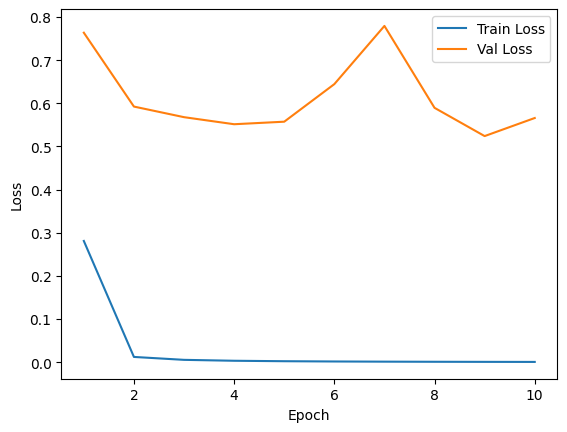

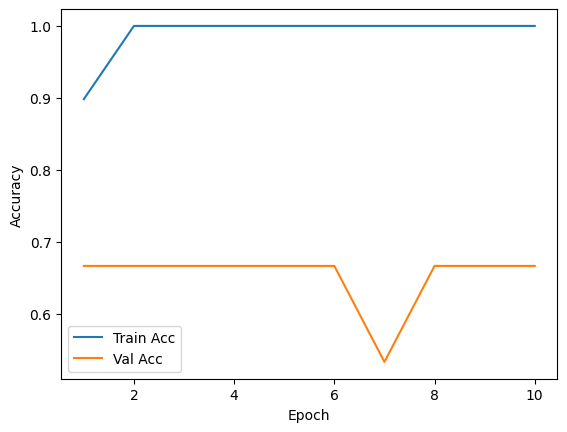

In [11]:
# After implementing logging in train.py to save loss/acc per epoch to logs.csv
logs = pd.read_csv('/content/logs.csv')

plt.figure()
plt.plot(logs.epoch, logs.train_loss, label='Train Loss')
plt.plot(logs.epoch, logs.val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(logs.epoch, logs.train_acc, label='Train Acc')
plt.plot(logs.epoch, logs.val_acc, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()